Linear Regression Expansion

In [ ]:
#If you are reading this, please note that I update the code for InLab 2 Part 2. It is not the default code for Linear Regression with Multiple Variables

import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
print("Current Working Directory:", os.getcwd())
print("Files/folders here:", os.listdir("."))

Current Working Directory: /home/emb/Desktop/MAPUA/6th year/1st Qtr/CPE178P/Lab 1/Lab 1 Codes
Files/folders here: ['experiment1.ipynb', 'experiment5.ipynb', '.venv', 'experiment3.ipynb', 'experiment4.ipynb', 'experiment2.ipynb', 'Dataset', 'tennis.pdf']


In [3]:
def generate_gradient(X, theta, y):
    sample_count = X.shape[0]
    # Calculate the gradient based on the matrix 1/m ∑(((h(x^i)-y^i)) x_j^i)
    return (1./sample_count)*X.T.dot(X.dot(theta)-y)

In [4]:
def simulate_multivariable_data(N):
    np.random.seed(42)
    # Simulate features 'area' and 'age' scaled between 0 and 1
    X_features = np.random.rand(N, 2) 
    
    # Add a column of 1s to represent the bias term (x_0 = 1)
    X = np.c_[np.ones((N, 1)), X_features]
    
    # Simulate y (price) using a hypothetical true relationship + some noise
    # true_theta = [Bias: 50, Area Weight: 100, Age Weight: -20]
    true_theta = np.array([[50], [100], [-20]])
    noise = np.random.randn(N, 1) * 5
    y = X.dot(true_theta) + noise
    
    return X, y

In [5]:
def get_training_data(file_path):
    orig_data = np.loadtxt(file_path,skiprows=1) # Ignore the title in the first row of the dataset.
    cols = orig_data.shape[1]
    return (orig_data, orig_data[:, :cols - 1], orig_data[:, cols-1:])

In [6]:
# Initialize the θ array.
def init_theta(feature_count):
    return np.ones(feature_count)

def gradient_descending(X, y, theta, alpha):
    Jthetas = []  
    index = 0
    gradient = generate_gradient(X, theta, y) 
    
    # End the calculation when the gradient is less than 0.0001 to prevent endless loops
    while not np.all(np.absolute(gradient) <= 1e-4):  
        theta = theta - alpha * gradient
        gradient = generate_gradient(X, theta, y) 
        
        # Calculate the loss function (Residual Sum of Squares)
        Jtheta = (X.dot(theta) - y).T.dot(X.dot(theta) - y)
        if (index + 1) % 10 == 0:
            Jthetas.append((index, Jtheta[0, 0]))  
        index += 1
        
        # Failsafe for unscaled data explosion
        if index > 50000:
            print("Reached max iterations. Stopping to prevent infinite loop.")
            break
            
    return theta, Jthetas

In [7]:
def showJTheta(diff_value):
    p_x = [val[0] for val in diff_value]
    p_y = [val[1] for val in diff_value]
    plt.plot(p_x, p_y, color='b')
    plt.xlabel('Steps')
    plt.ylabel('Loss function')
    plt.title('Step - Loss Function Curve')
    plt.show()

In [8]:
def show_regression_surface(theta, X, y):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract features for plotting
    area = X[:, 1]
    age = X[:, 2]
    price = y.flatten()
    
    # Scatter the simulated data points
    ax.scatter(area, age, price, color='b', marker='x', label="Sample Data")
    
    # Create the regression plane
    area_range = np.linspace(min(area), max(area), 10)
    age_range = np.linspace(min(age), max(age), 10)
    Area_grid, Age_grid = np.meshgrid(area_range, age_range)
    
    # z = theta_0 + theta_1*Area + theta_2*Age
    Price_pred = theta[0, 0] + theta[1, 0] * Area_grid + theta[2, 0] * Age_grid
    
    ax.plot_surface(Area_grid, Age_grid, Price_pred, alpha=0.5, color='r', label="Regression Plane")
    ax.set_xlabel('Area')
    ax.set_ylabel('Age')
    ax.set_zlabel('Price')
    ax.set_title('Multivariable Linear Regression Plane')
    plt.show()

Running gradient descent...
Optimal Parameters:
Bias (b):  1.5042
Weight 1:  1.5042
Weight 2:  1.6671


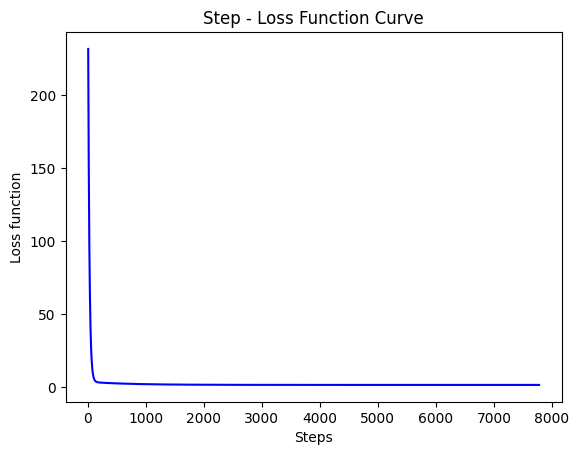

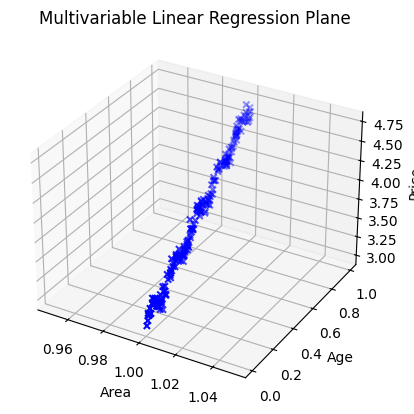

In [ ]:
# 1. Load data
file_path = "Dataset/ML/02/lr2_data.txt"
training_data_include_y, training_x_raw, y = get_training_data(file_path)

# 2. Add the bias term (x_0 = 1) to the feature matrix
sample_count = training_x_raw.shape[0]
X_with_bias = np.c_[np.ones((sample_count, 1)), training_x_raw]

# Obtain the numbers of samples and features (should be 3 features now: bias, area, age)
sample_count, feature_count = X_with_bias.shape

# 3. Define the learning step α and initialize θ
alpha = 0.01 
theta = init_theta(feature_count)

# Force strict 2D column vector shapes to prevent broadcasting explosions
y = y.reshape(-1, 1)
theta = theta.reshape(-1, 1)

# 4. Perform Gradient Descent
print("Running gradient descent...")
result_theta, Jthetas = gradient_descending(X_with_bias, y, theta, alpha)

# 5. Display the parameters
print("Optimal Parameters:")
print(f"Bias (b):  {result_theta[0, 0]:.4f}")
print(f"Weight 1:  {result_theta[1, 0]:.4f}")
print(f"Weight 2:  {result_theta[2, 0]:.4f}")

# 6. Show visuals
showJTheta(Jthetas)
show_regression_surface(result_theta, X_with_bias, y)